<a href="https://colab.research.google.com/github/lswoodentoys/research_paper/blob/main/h%E1%BB%87_s%E1%BB%91_t%C6%B0%C6%A1ng_quan_G177_vs_UVA340.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [32]:
import pandas as pd

file_path = '/content/drive/MyDrive/Python_study/datasets/spectral_data.csv'
df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (121, 3)


,Wavelength_nm,I_G177,I_UVA340
0,280,0.01,-
1,281,0.01,-
2,282,0.01,-
3,283,0.01,-
4,284,0.01,-


Dữ liệu ban đầu:
   Wavelength_nm  I_G177 I_UVA340
0            280    0.01     -   
1            281    0.01     -   
2            282    0.01     -   
3            283    0.01     -   
4            284    0.01     -   

===== KẾT QUẢ TÍNH TOÁN =====
Khoảng bước sóng: 295 - 360 nm
Số điểm dữ liệu: 65
Tổng chi-square: 2.00624220
Giá trị căn bậc hai: 0.17568513
Hệ số R: 0.82431487

Đã xuất bảng kết quả:
spectral_calculation_results.csv


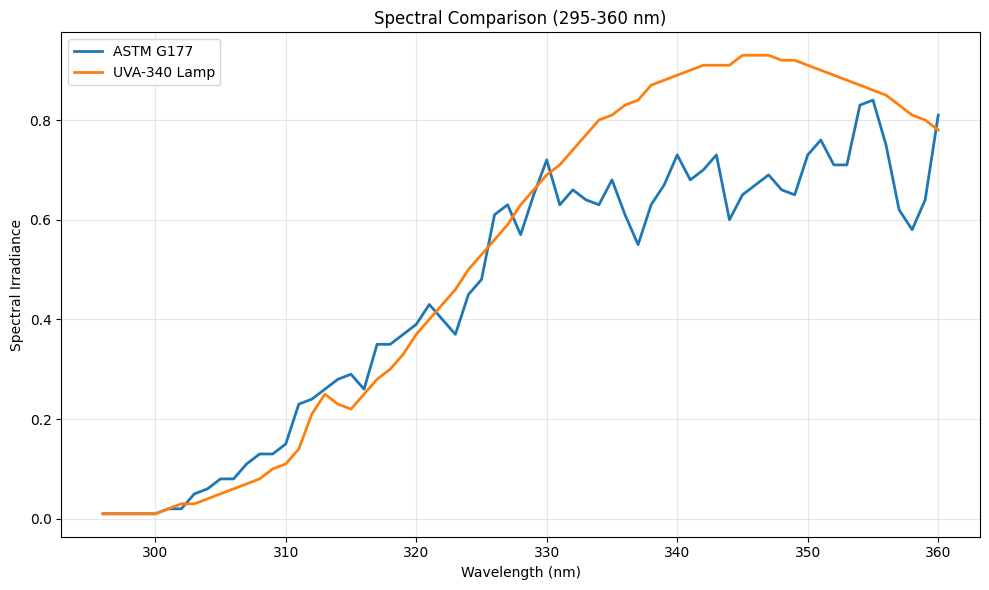

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

comparison_results = []

# =====================================================
# 1. ĐỌC DỮ LIỆU PHỔ
# =====================================================

# File CSV chứa 3 cột:
# Wavelength_nm, I_G177, I_UVA340

file_path = '/content/drive/MyDrive/Python_study/datasets/spectral_data.csv'
df = pd.read_csv(file_path)

# Clean column names by stripping whitespace
df.columns = df.columns.str.strip()

print("Dữ liệu ban đầu:")
print(df.head())


# =====================================================
# 2. THIẾT LẬP KHOẢNG BƯỚC SÓNG
# =====================================================

lambda_min = 295  # Bước sóng giới hạn dưới (nm)
lambda_max = 360  # Bước sóng giới hạn trên (nm)


# =====================================================
# 3. LỌC VÀ ĐỒNG BỘ DỮ LIỆU
# =====================================================

df = df[
    (df["Wavelength_nm"] >= lambda_min) &
    (df["Wavelength_nm"] <= lambda_max)
].copy()

# Chuyển dữ liệu thành dạng số
columns = ["Wavelength_nm", "I_G177", "I_UVA340"]

for col in columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Loại bỏ dữ liệu không hợp lệ
df = df.dropna(subset=columns)

# Filter out rows where I_G177 is not positive to avoid division by zero
df = df[df["I_G177"] > 0].copy()

# Sắp xếp theo bước sóng
df = df.sort_values("Wavelength_nm")

# Nếu có bước sóng trùng nhau, tính giá trị trung bình
df = df.groupby(
    "Wavelength_nm",
    as_index=False
)[["I_G177", "I_UVA340"]].mean()

# The check for I_G177 <= 0 is no longer needed here after filtering
# if (df["I_G177"] <= 0).any():
#     raise ValueError(
#         "I_G177 phải lớn hơn 0 tại mọi bước sóng được tính."
#     )

if len(df) < 2:
    raise ValueError(
        "Không đủ dữ liệu trong khoảng bước sóng đã chọn."
        "Sau khi lọc các giá trị I_G177 <= 0." # Added clarification
    )


# =====================================================
# 4. TÍNH SAI KHÁC PHỔ TẠI TỪNG BƯỚC SÓNG
# =====================================================

df["Difference"] = (
    df["I_G177"] - df["I_UVA340"]
)

df["Squared_Difference"] = (
    df["Difference"] ** 2
)

df["Chi_Square_Term"] = (
    df["Squared_Difference"] / df["I_G177"]
)


# =====================================================
# 5. TÍNH HỆ SỐ THEO CÔNG THỨC TRONG HÌNH
# =====================================================

# Tổng các thành phần chi-square
chi_square_sum = df["Chi_Square_Term"].sum()

# Số khoảng bước sóng theo công thức
denominator = lambda_max - lambda_min

# Sai khác phổ
standard_deviation = np.sqrt(
    chi_square_sum / denominator
)

# Hệ số tương đồng phổ
R = 1 - standard_deviation


# =====================================================
# 6. HIỂN THỊ KẾT QUẢ
# =====================================================

print("\n===== KẾT QUẢ TÍNH TOÁN =====")

print(f"Khoảng bước sóng: "
      f"{lambda_min} - {lambda_max} nm")

print(f"Số điểm dữ liệu: {len(df)}")

print(f"Tổng chi-square: {chi_square_sum:.8f}")

print(f"Giá trị căn bậc hai: "
      f"{standard_deviation:.8f}")

print(f"Hệ số R: {R:.8f}")


# =====================================================
# 7. XUẤT BẢNG KẾT QUẢ
# =====================================================

df.to_csv(
    "spectral_calculation_results.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nĐã xuất bảng kết quả:")
print("spectral_calculation_results.csv")


# =====================================================
# 8. VẼ BIỂU ĐỒ SO SÁNH PHỔ
# =====================================================

plt.figure(figsize=(10, 6))

plt.plot(
    df["Wavelength_nm"],
    df["I_G177"],
    label="ASTM G177",
    linewidth=2
)

plt.plot(
    df["Wavelength_nm"],
    df["I_UVA340"],
    label="UVA-340 Lamp",
    linewidth=2
)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Spectral Irradiance")

plt.title(
    f"Spectral Comparison ({lambda_min}-{lambda_max} nm)"
)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "spectral_comparison.png",
    dpi=300
)

plt.show()

In [68]:
comparison_results.append({
    "Wavelength_Range": f"{lambda_min}-{lambda_max} nm",
    "Lambda_Min_nm": lambda_min,
    "Lambda_Max_nm": lambda_max,
    "Data_Points": len(df),
    "Chi_Square_Sum": chi_square_sum,
    "Standard_Deviation": standard_deviation,
    "R": R
})

## So sánh với dải phổ 295-385nm

Dữ liệu ban đầu:
   Wavelength_nm  I_G177 I_UVA340
0            280    0.01     -   
1            281    0.01     -   
2            282    0.01     -   
3            283    0.01     -   
4            284    0.01     -   

===== KẾT QUẢ TÍNH TOÁN =====
Khoảng bước sóng: 295 - 385 nm
Số điểm dữ liệu: 90
Tổng chi-square: 5.91756317
Giá trị căn bậc hai: 0.25641900
Hệ số R: 0.74358100

Đã xuất bảng kết quả:
spectral_calculation_results.csv


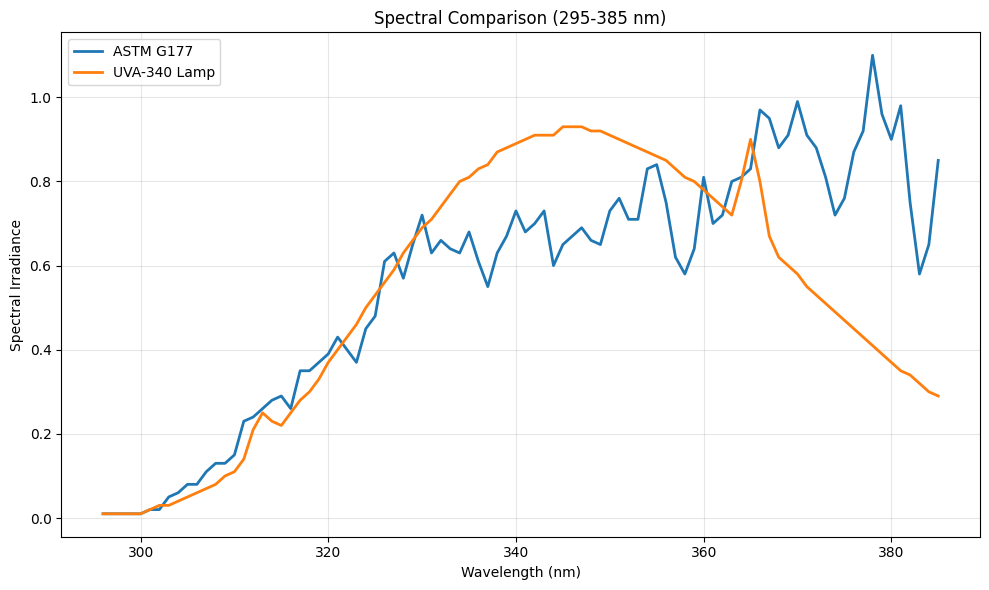

In [83]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================
# 1. ĐỌC DỮ LIỆU PHỔ
# =====================================================

# File CSV chứa 3 cột:
# Wavelength_nm, I_G177, I_UVA340

file_path = '/content/drive/MyDrive/Python_study/datasets/spectral_data.csv'
df = pd.read_csv(file_path)

# Clean column names by stripping whitespace
df.columns = df.columns.str.strip()

print("Dữ liệu ban đầu:")
print(df.head())


# =====================================================
# 2. THIẾT LẬP KHOẢNG BƯỚC SÓNG
# =====================================================

lambda_min = 295  # Bước sóng giới hạn dưới (nm)
lambda_max = 385  # Bước sóng giới hạn trên (nm)


# =====================================================
# 3. LỌC VÀ ĐỒNG BỘ DỮ LIỆU
# =====================================================

df = df[
    (df["Wavelength_nm"] >= lambda_min) &
    (df["Wavelength_nm"] <= lambda_max)
].copy()

# Chuyển dữ liệu thành dạng số
columns = ["Wavelength_nm", "I_G177", "I_UVA340"]

for col in columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Loại bỏ dữ liệu không hợp lệ
df = df.dropna(subset=columns)

# Filter out rows where I_G177 is not positive to avoid division by zero
df = df[df["I_G177"] > 0].copy()

# Sắp xếp theo bước sóng
df = df.sort_values("Wavelength_nm")

# Nếu có bước sóng trùng nhau, tính giá trị trung bình
df = df.groupby(
    "Wavelength_nm",
    as_index=False
)[["I_G177", "I_UVA340"]].mean()

# The check for I_G177 <= 0 is no longer needed here after filtering
# if (df["I_G177"] <= 0).any():
#     raise ValueError(
#         "I_G177 phải lớn hơn 0 tại mọi bước sóng được tính."
#     )

if len(df) < 2:
    raise ValueError(
        "Không đủ dữ liệu trong khoảng bước sóng đã chọn."
        "Sau khi lọc các giá trị I_G177 <= 0." # Added clarification
    )


# =====================================================
# 4. TÍNH SAI KHÁC PHỔ TẠI TỪNG BƯỚC SÓNG
# =====================================================

df["Difference"] = (
    df["I_G177"] - df["I_UVA340"]
)

df["Squared_Difference"] = (
    df["Difference"] ** 2
)

df["Chi_Square_Term"] = (
    df["Squared_Difference"] / df["I_G177"]
)


# =====================================================
# 5. TÍNH HỆ SỐ THEO CÔNG THỨC TRONG HÌNH
# =====================================================

# Tổng các thành phần chi-square
chi_square_sum = df["Chi_Square_Term"].sum()

# Số khoảng bước sóng theo công thức
denominator = lambda_max - lambda_min

# Sai khác phổ
standard_deviation = np.sqrt(
    chi_square_sum / denominator
)

# Hệ số tương đồng phổ
R = 1 - standard_deviation


# =====================================================
# 6. HIỂN THỊ KẾT QUẢ
# =====================================================

print("\n===== KẾT QUẢ TÍNH TOÁN =====")

print(f"Khoảng bước sóng: "
      f"{lambda_min} - {lambda_max} nm")

print(f"Số điểm dữ liệu: {len(df)}")

print(f"Tổng chi-square: {chi_square_sum:.8f}")

print(f"Giá trị căn bậc hai: "
      f"{standard_deviation:.8f}")

print(f"Hệ số R: {R:.8f}")


# =====================================================
# 7. XUẤT BẢNG KẾT QUẢ
# =====================================================

df.to_csv(
    "spectral_calculation_results.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nĐã xuất bảng kết quả:")
print("spectral_calculation_results.csv")


# =====================================================
# 8. VẼ BIỂU ĐỒ SO SÁNH PHỔ
# =====================================================

plt.figure(figsize=(10, 6))

plt.plot(
    df["Wavelength_nm"],
    df["I_G177"],
    label="ASTM G177",
    linewidth=2
)

plt.plot(
    df["Wavelength_nm"],
    df["I_UVA340"],
    label="UVA-340 Lamp",
    linewidth=2
)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Spectral Irradiance")

plt.title(
    f"Spectral Comparison ({lambda_min}-{lambda_max} nm)"
)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "spectral_comparison.png",
    dpi=300
)

plt.show()

In [84]:
comparison_results.append({
    "Wavelength_Range": f"{lambda_min}-{lambda_max} nm",
    "Lambda_Min_nm": lambda_min,
    "Lambda_Max_nm": lambda_max,
    "Data_Points": len(df),
    "Chi_Square_Sum": chi_square_sum,
    "Standard_Deviation": standard_deviation,
    "R": R
})

## So sánh với dải phổ 295-370 nm

Dữ liệu ban đầu:
   Wavelength_nm  I_G177 I_UVA340
0            280    0.01     -   
1            281    0.01     -   
2            282    0.01     -   
3            283    0.01     -   
4            284    0.01     -   

===== KẾT QUẢ TÍNH TOÁN =====
Khoảng bước sóng: 295 - 370 nm
Số điểm dữ liệu: 75
Tổng chi-square: 2.49050837
Giá trị căn bậc hai: 0.18222727
Hệ số R: 0.81777273

Đã xuất bảng kết quả:
spectral_calculation_results.csv


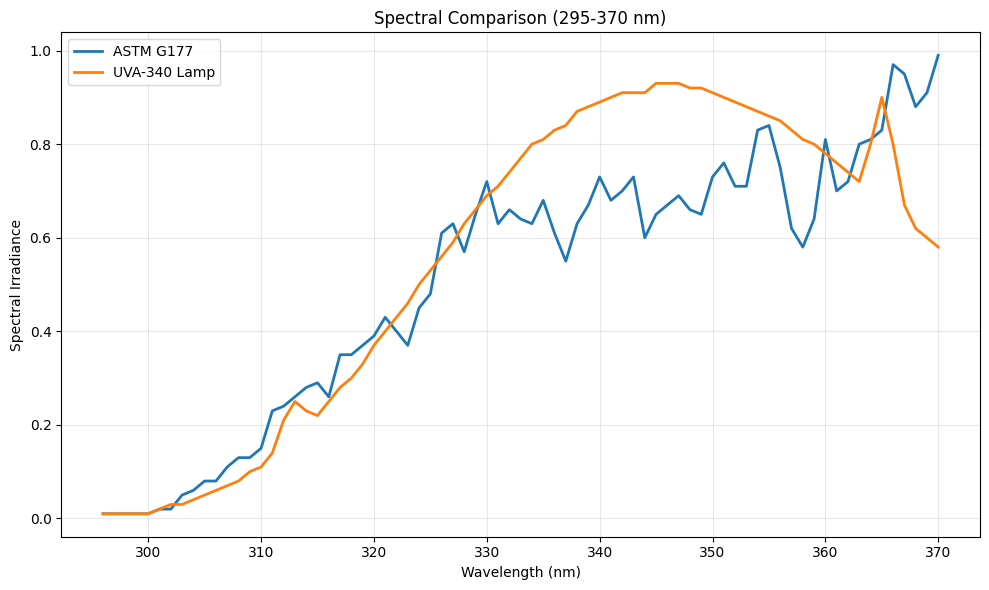

In [85]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================
# 1. ĐỌC DỮ LIỆU PHỔ
# =====================================================

# File CSV chứa 3 cột:
# Wavelength_nm, I_G177, I_UVA340

file_path = '/content/drive/MyDrive/Python_study/datasets/spectral_data.csv'
df = pd.read_csv(file_path)

# Clean column names by stripping whitespace
df.columns = df.columns.str.strip()

print("Dữ liệu ban đầu:")
print(df.head())


# =====================================================
# 2. THIẾT LẬP KHOẢNG BƯỚC SÓNG
# =====================================================

lambda_min = 295  # Bước sóng giới hạn dưới (nm)
lambda_max = 370  # Bước sóng giới hạn trên (nm)


# =====================================================
# 3. LỌC VÀ ĐỒNG BỘ DỮ LIỆU
# =====================================================

df = df[
    (df["Wavelength_nm"] >= lambda_min) &
    (df["Wavelength_nm"] <= lambda_max)
].copy()

# Chuyển dữ liệu thành dạng số
columns = ["Wavelength_nm", "I_G177", "I_UVA340"]

for col in columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Loại bỏ dữ liệu không hợp lệ
df = df.dropna(subset=columns)

# Filter out rows where I_G177 is not positive to avoid division by zero
df = df[df["I_G177"] > 0].copy()

# Sắp xếp theo bước sóng
df = df.sort_values("Wavelength_nm")

# Nếu có bước sóng trùng nhau, tính giá trị trung bình
df = df.groupby(
    "Wavelength_nm",
    as_index=False
)[["I_G177", "I_UVA340"]].mean()

# The check for I_G177 <= 0 is no longer needed here after filtering
# if (df["I_G177"] <= 0).any():
#     raise ValueError(
#         "I_G177 phải lớn hơn 0 tại mọi bước sóng được tính."
#     )

if len(df) < 2:
    raise ValueError(
        "Không đủ dữ liệu trong khoảng bước sóng đã chọn."
        "Sau khi lọc các giá trị I_G177 <= 0." # Added clarification
    )


# =====================================================
# 4. TÍNH SAI KHÁC PHỔ TẠI TỪNG BƯỚC SÓNG
# =====================================================

df["Difference"] = (
    df["I_G177"] - df["I_UVA340"]
)

df["Squared_Difference"] = (
    df["Difference"] ** 2
)

df["Chi_Square_Term"] = (
    df["Squared_Difference"] / df["I_G177"]
)


# =====================================================
# 5. TÍNH HỆ SỐ THEO CÔNG THỨC TRONG HÌNH
# =====================================================

# Tổng các thành phần chi-square
chi_square_sum = df["Chi_Square_Term"].sum()

# Số khoảng bước sóng theo công thức
denominator = lambda_max - lambda_min

# Sai khác phổ
standard_deviation = np.sqrt(
    chi_square_sum / denominator
)

# Hệ số tương đồng phổ
R = 1 - standard_deviation


# =====================================================
# 6. HIỂN THỊ KẾT QUẢ
# =====================================================

print("\n===== KẾT QUẢ TÍNH TOÁN =====")

print(f"Khoảng bước sóng: "
      f"{lambda_min} - {lambda_max} nm")

print(f"Số điểm dữ liệu: {len(df)}")

print(f"Tổng chi-square: {chi_square_sum:.8f}")

print(f"Giá trị căn bậc hai: "
      f"{standard_deviation:.8f}")

print(f"Hệ số R: {R:.8f}")


# =====================================================
# 7. XUẤT BẢNG KẾT QUẢ
# =====================================================

df.to_csv(
    "spectral_calculation_results.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nĐã xuất bảng kết quả:")
print("spectral_calculation_results.csv")


# =====================================================
# 8. VẼ BIỂU ĐỒ SO SÁNH PHỔ
# =====================================================

plt.figure(figsize=(10, 6))

plt.plot(
    df["Wavelength_nm"],
    df["I_G177"],
    label="ASTM G177",
    linewidth=2
)

plt.plot(
    df["Wavelength_nm"],
    df["I_UVA340"],
    label="UVA-340 Lamp",
    linewidth=2
)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Spectral Irradiance")

plt.title(
    f"Spectral Comparison ({lambda_min}-{lambda_max} nm)"
)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "spectral_comparison.png",
    dpi=300
)

plt.show()

In [86]:
comparison_results.append({
    "Wavelength_Range": f"{lambda_min}-{lambda_max} nm",
    "Lambda_Min_nm": lambda_min,
    "Lambda_Max_nm": lambda_max,
    "Data_Points": len(df),
    "Chi_Square_Sum": chi_square_sum,
    "Standard_Deviation": standard_deviation,
    "R": R
})

## So sánh với dải phổ 295-350nm

Dữ liệu ban đầu:
   Wavelength_nm  I_G177 I_UVA340
0            280    0.01     -   
1            281    0.01     -   
2            282    0.01     -   
3            283    0.01     -   
4            284    0.01     -   

===== KẾT QUẢ TÍNH TOÁN =====
Khoảng bước sóng: 295 - 350 nm
Số điểm dữ liệu: 55
Tổng chi-square: 1.67493042
Giá trị căn bậc hai: 0.17450868
Hệ số R: 0.82549132

Đã xuất bảng kết quả:
spectral_calculation_results.csv


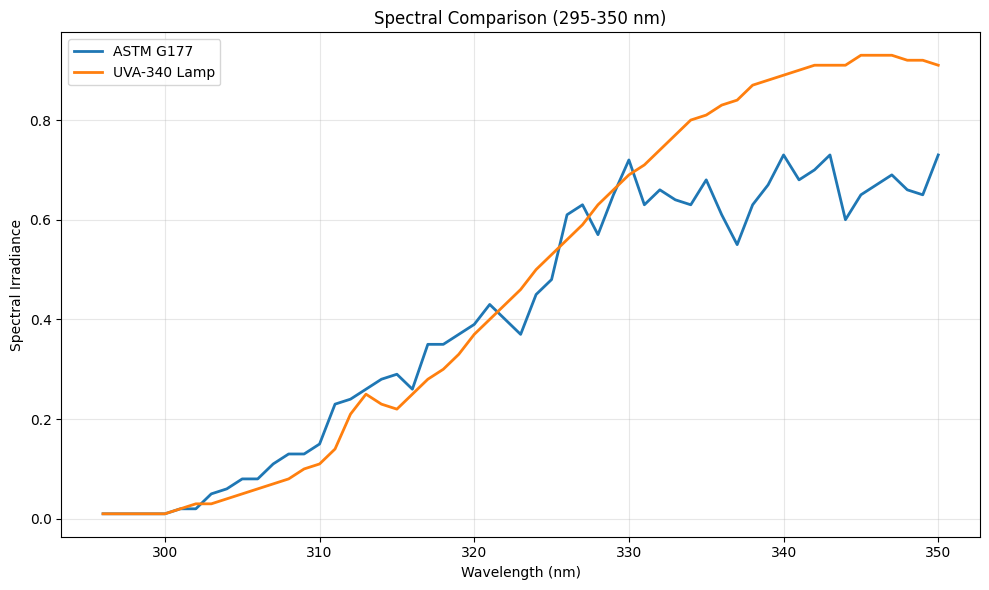

In [87]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =====================================================
# 1. ĐỌC DỮ LIỆU PHỔ
# =====================================================

# File CSV chứa 3 cột:
# Wavelength_nm, I_G177, I_UVA340

file_path = '/content/drive/MyDrive/Python_study/datasets/spectral_data.csv'
df = pd.read_csv(file_path)

# Clean column names by stripping whitespace
df.columns = df.columns.str.strip()

print("Dữ liệu ban đầu:")
print(df.head())


# =====================================================
# 2. THIẾT LẬP KHOẢNG BƯỚC SÓNG
# =====================================================

lambda_min = 295  # Bước sóng giới hạn dưới (nm)
lambda_max = 350  # Bước sóng giới hạn trên (nm)


# =====================================================
# 3. LỌC VÀ ĐỒNG BỘ DỮ LIỆU
# =====================================================

df = df[
    (df["Wavelength_nm"] >= lambda_min) &
    (df["Wavelength_nm"] <= lambda_max)
].copy()

# Chuyển dữ liệu thành dạng số
columns = ["Wavelength_nm", "I_G177", "I_UVA340"]

for col in columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Loại bỏ dữ liệu không hợp lệ
df = df.dropna(subset=columns)

# Filter out rows where I_G177 is not positive to avoid division by zero
df = df[df["I_G177"] > 0].copy()

# Sắp xếp theo bước sóng
df = df.sort_values("Wavelength_nm")

# Nếu có bước sóng trùng nhau, tính giá trị trung bình
df = df.groupby(
    "Wavelength_nm",
    as_index=False
)[["I_G177", "I_UVA340"]].mean()

# The check for I_G177 <= 0 is no longer needed here after filtering
# if (df["I_G177"] <= 0).any():
#     raise ValueError(
#         "I_G177 phải lớn hơn 0 tại mọi bước sóng được tính."
#     )

if len(df) < 2:
    raise ValueError(
        "Không đủ dữ liệu trong khoảng bước sóng đã chọn."
        "Sau khi lọc các giá trị I_G177 <= 0." # Added clarification
    )


# =====================================================
# 4. TÍNH SAI KHÁC PHỔ TẠI TỪNG BƯỚC SÓNG
# =====================================================

df["Difference"] = (
    df["I_G177"] - df["I_UVA340"]
)

df["Squared_Difference"] = (
    df["Difference"] ** 2
)

df["Chi_Square_Term"] = (
    df["Squared_Difference"] / df["I_G177"]
)


# =====================================================
# 5. TÍNH HỆ SỐ THEO CÔNG THỨC TRONG HÌNH
# =====================================================

# Tổng các thành phần chi-square
chi_square_sum = df["Chi_Square_Term"].sum()

# Số khoảng bước sóng theo công thức
denominator = lambda_max - lambda_min

# Sai khác phổ
standard_deviation = np.sqrt(
    chi_square_sum / denominator
)

# Hệ số tương đồng phổ
R = 1 - standard_deviation


# =====================================================
# 6. HIỂN THỊ KẾT QUẢ
# =====================================================

print("\n===== KẾT QUẢ TÍNH TOÁN =====")

print(f"Khoảng bước sóng: "
      f"{lambda_min} - {lambda_max} nm")

print(f"Số điểm dữ liệu: {len(df)}")

print(f"Tổng chi-square: {chi_square_sum:.8f}")

print(f"Giá trị căn bậc hai: "
      f"{standard_deviation:.8f}")

print(f"Hệ số R: {R:.8f}")


# =====================================================
# 7. XUẤT BẢNG KẾT QUẢ
# =====================================================

df.to_csv(
    "spectral_calculation_results.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nĐã xuất bảng kết quả:")
print("spectral_calculation_results.csv")


# =====================================================
# 8. VẼ BIỂU ĐỒ SO SÁNH PHỔ
# =====================================================

plt.figure(figsize=(10, 6))

plt.plot(
    df["Wavelength_nm"],
    df["I_G177"],
    label="ASTM G177",
    linewidth=2
)

plt.plot(
    df["Wavelength_nm"],
    df["I_UVA340"],
    label="UVA-340 Lamp",
    linewidth=2
)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Spectral Irradiance")

plt.title(
    f"Spectral Comparison ({lambda_min}-{lambda_max} nm)"
)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "spectral_comparison.png",
    dpi=300
)

plt.show()

In [90]:
comparison_results.append({
    "Wavelength_Range": f"{lambda_min}-{lambda_max} nm",
    "Lambda_Min_nm": lambda_min,
    "Lambda_Max_nm": lambda_max,
    "Data_Points": len(df),
    "Chi_Square_Sum": chi_square_sum,
    "Standard_Deviation": standard_deviation,
    "R": R
})

## So sánh với dải phổ 295-380nm

Dữ liệu ban đầu:
   Wavelength_nm  I_G177 I_UVA340
0            280    0.01     -   
1            281    0.01     -   
2            282    0.01     -   
3            283    0.01     -   
4            284    0.01     -   

===== KẾT QUẢ TÍNH TOÁN =====
Khoảng bước sóng: 295 - 380 nm
Số điểm dữ liệu: 85
Tổng chi-square: 4.61447540
Giá trị căn bậc hai: 0.23299774
Hệ số R: 0.76700226

Đã xuất bảng kết quả:
spectral_calculation_results.csv


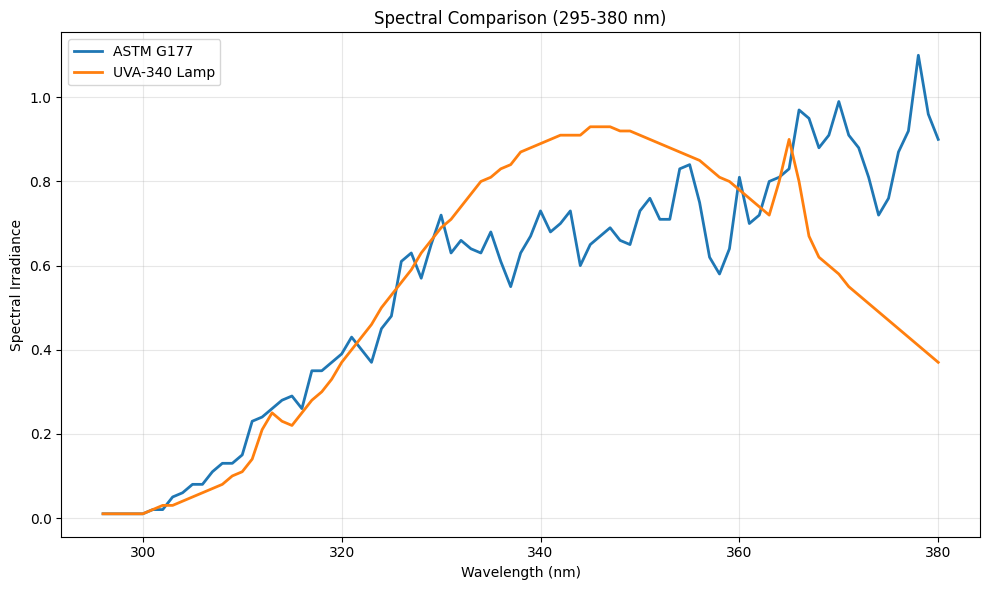

In [89]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =====================================================
# 1. ĐỌC DỮ LIỆU PHỔ
# =====================================================

# File CSV chứa 3 cột:
# Wavelength_nm, I_G177, I_UVA340

file_path = '/content/drive/MyDrive/Python_study/datasets/spectral_data.csv'
df = pd.read_csv(file_path)

# Clean column names by stripping whitespace
df.columns = df.columns.str.strip()

print("Dữ liệu ban đầu:")
print(df.head())


# =====================================================
# 2. THIẾT LẬP KHOẢNG BƯỚC SÓNG
# =====================================================

lambda_min = 295  # Bước sóng giới hạn dưới (nm)
lambda_max = 380  # Bước sóng giới hạn trên (nm)


# =====================================================
# 3. LỌC VÀ ĐỒNG BỘ DỮ LIỆU
# =====================================================

df = df[
    (df["Wavelength_nm"] >= lambda_min) &
    (df["Wavelength_nm"] <= lambda_max)
].copy()

# Chuyển dữ liệu thành dạng số
columns = ["Wavelength_nm", "I_G177", "I_UVA340"]

for col in columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Loại bỏ dữ liệu không hợp lệ
df = df.dropna(subset=columns)

# Filter out rows where I_G177 is not positive to avoid division by zero
df = df[df["I_G177"] > 0].copy()

# Sắp xếp theo bước sóng
df = df.sort_values("Wavelength_nm")

# Nếu có bước sóng trùng nhau, tính giá trị trung bình
df = df.groupby(
    "Wavelength_nm",
    as_index=False
)[["I_G177", "I_UVA340"]].mean()

# The check for I_G177 <= 0 is no longer needed here after filtering
# if (df["I_G177"] <= 0).any():
#     raise ValueError(
#         "I_G177 phải lớn hơn 0 tại mọi bước sóng được tính."
#     )

if len(df) < 2:
    raise ValueError(
        "Không đủ dữ liệu trong khoảng bước sóng đã chọn."
        "Sau khi lọc các giá trị I_G177 <= 0." # Added clarification
    )


# =====================================================
# 4. TÍNH SAI KHÁC PHỔ TẠI TỪNG BƯỚC SÓNG
# =====================================================

df["Difference"] = (
    df["I_G177"] - df["I_UVA340"]
)

df["Squared_Difference"] = (
    df["Difference"] ** 2
)

df["Chi_Square_Term"] = (
    df["Squared_Difference"] / df["I_G177"]
)


# =====================================================
# 5. TÍNH HỆ SỐ THEO CÔNG THỨC TRONG HÌNH
# =====================================================

# Tổng các thành phần chi-square
chi_square_sum = df["Chi_Square_Term"].sum()

# Số khoảng bước sóng theo công thức
denominator = lambda_max - lambda_min

# Sai khác phổ
standard_deviation = np.sqrt(
    chi_square_sum / denominator
)

# Hệ số tương đồng phổ
R = 1 - standard_deviation


# =====================================================
# 6. HIỂN THỊ KẾT QUẢ
# =====================================================

print("\n===== KẾT QUẢ TÍNH TOÁN =====")

print(f"Khoảng bước sóng: "
      f"{lambda_min} - {lambda_max} nm")

print(f"Số điểm dữ liệu: {len(df)}")

print(f"Tổng chi-square: {chi_square_sum:.8f}")

print(f"Giá trị căn bậc hai: "
      f"{standard_deviation:.8f}")

print(f"Hệ số R: {R:.8f}")


# =====================================================
# 7. XUẤT BẢNG KẾT QUẢ
# =====================================================

df.to_csv(
    "spectral_calculation_results.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nĐã xuất bảng kết quả:")
print("spectral_calculation_results.csv")


# =====================================================
# 8. VẼ BIỂU ĐỒ SO SÁNH PHỔ
# =====================================================

plt.figure(figsize=(10, 6))

plt.plot(
    df["Wavelength_nm"],
    df["I_G177"],
    label="ASTM G177",
    linewidth=2
)

plt.plot(
    df["Wavelength_nm"],
    df["I_UVA340"],
    label="UVA-340 Lamp",
    linewidth=2
)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Spectral Irradiance")

plt.title(
    f"Spectral Comparison ({lambda_min}-{lambda_max} nm)"
)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "spectral_comparison.png",
    dpi=300
)

plt.show()

In [91]:
comparison_results.append({
    "Wavelength_Range": f"{lambda_min}-{lambda_max} nm",
    "Lambda_Min_nm": lambda_min,
    "Lambda_Max_nm": lambda_max,
    "Data_Points": len(df),
    "Chi_Square_Sum": chi_square_sum,
    "Standard_Deviation": standard_deviation,
    "R": R
})

# Bảng Tổng Hợp Kết Quả

In [95]:
import pandas as pd
from IPython.display import display, HTML

# =====================================================
# 1. TỔNG HỢP TẤT CẢ KẾT QUẢ ĐÃ LƯU
# =====================================================

df_comparison = pd.DataFrame(comparison_results)

if df_comparison.empty:
    raise ValueError(
        "Chưa có kết quả. Hãy chạy các bước tính toán trước."
    )


# =====================================================
# 2. SẮP XẾP R TỪ LỚN ĐẾN NHỎ
# =====================================================

df_comparison = (
    df_comparison
    .sort_values(
        by="R",
        ascending=False
    )
    .reset_index(drop=True)
)

# Đánh số thứ tự theo thứ hạng R
df_comparison.insert(
    0,
    "Rank",
    range(1, len(df_comparison) + 1)
)


# =====================================================
# 3. HIỂN THỊ BẢNG FULL WIDTH
# =====================================================

display(HTML("""
<style>
.output_area,
.output_html,
.jp-RenderedHTMLCommon {
    width: 100% !important;
    max-width: 100% !important;
}

table.dataframe {
    width: 100% !important;
    table-layout: auto !important;
}

table.dataframe th,
table.dataframe td {
    text-align: center !important;
    padding: 10px !important;
    white-space: nowrap;
}
</style>
"""))

display(
    df_comparison.style.format({
        "Chi_Square_Sum": "{:.7f}",
        "Standard_Deviation": "{:.7f}",
        "R": "{:.7f}"
    })
)


# =====================================================
# 4. XUẤT FILE CSV
# =====================================================

df_comparison.to_csv(
    "spectral_comparison_summary.csv",
    index=False,
    encoding="utf-8-sig",
    float_format="%.8f"
)


# =====================================================
# 5. XUẤT FILE EXCEL
# =====================================================

df_comparison.to_excel(
    "spectral_comparison_summary.xlsx",
    index=False,
    sheet_name="Comparison"
)

print("NẾU MUỐN LẤY DỮ LIỆU MỚI NHẤT VỪA CHẠY ĐƯỢC, HÃY CHẠY LẠI CELL COMPARISON Ở TRÊN CÙNG!")
print("Đã sắp xếp R từ lớn đến nhỏ.")
print(f"Tổng số kết quả: {len(df_comparison)}")
print("Đã xuất file CSV và Excel.")

,Rank,Wavelength_Range,Lambda_Min_nm,Lambda_Max_nm,Data_Points,Chi_Square_Sum,Standard_Deviation,R
0,1,285-350 nm,285,350,55,1.6749304,0.1605246,0.8394754
1,2,285-370 nm,285,370,75,2.4905084,0.1711727,0.8288273
2,3,295-350 nm,295,350,55,1.6749304,0.1745087,0.8254913
3,4,295-360 nm,295,360,65,2.0062422,0.1756851,0.8243149
4,5,295-370 nm,295,370,75,2.4905084,0.1822273,0.8177727
5,6,285-380 nm,285,380,85,4.6144754,0.2203938,0.7796062
6,7,295-380 nm,295,380,85,4.6144754,0.2329977,0.7670023
7,8,295-380 nm,295,380,85,4.6144754,0.2329977,0.7670023
8,9,285-385 nm,285,385,90,5.9175632,0.2432604,0.7567396
9,10,295-385 nm,295,385,90,5.9175632,0.2564190,0.7435810


NẾU MUỐN LẤY DỮ LIỆU MỚI NHẤT VỪA CHẠY ĐƯỢC, HÃY CHẠY LẠI CELL COMPARISON Ở TRÊN CÙNG!
Đã sắp xếp R từ lớn đến nhỏ.
Tổng số kết quả: 10
Đã xuất file CSV và Excel.
